In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

train_data = datasets.MNIST(root='../data', download=True, train=True, transform=transforms.ToTensor())
test_data = datasets.MNIST(root='../data', download=True, train=False, transform=transforms.ToTensor())
 
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f'Train Data Size: {len(train_data)} Test Data Size: {len(test_data)}')

Train Data Size: 60000 Test Data Size: 10000


Sample Test Data: 7


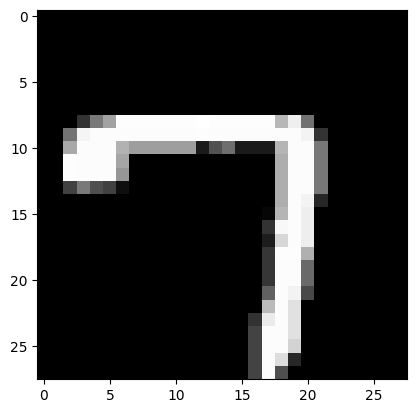

In [2]:
sample = np.random.randint(len(train_data))
sample_train_X = train_data[sample][0].squeeze()
sample_train_y = train_data[sample][1]

print(f'Sample Test Data: {sample_train_y}')

plt.imshow(sample_train_X, cmap='grey')

In [3]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 16)
        self.fc2 = nn.Linear(16, 16)
        self.out = nn.Linear(16, 10)
    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

model = NeuralNetwork()

print([layer for layer in model.parameters()])

[Parameter containing:
tensor([[ 0.0273, -0.0027, -0.0277,  ..., -0.0178,  0.0137,  0.0081],
        [ 0.0235,  0.0278,  0.0267,  ...,  0.0005,  0.0035,  0.0231],
        [-0.0054, -0.0079,  0.0221,  ...,  0.0038,  0.0342,  0.0092],
        ...,
        [ 0.0238,  0.0130, -0.0155,  ...,  0.0328, -0.0200, -0.0237],
        [-0.0105,  0.0252, -0.0064,  ...,  0.0350, -0.0316, -0.0119],
        [-0.0168,  0.0060,  0.0023,  ..., -0.0338,  0.0277, -0.0094]],
       requires_grad=True), Parameter containing:
tensor([-0.0068,  0.0055, -0.0022,  0.0240,  0.0227, -0.0047,  0.0325,  0.0044,
        -0.0139,  0.0180, -0.0328,  0.0308, -0.0133,  0.0137,  0.0124, -0.0109],
       requires_grad=True), Parameter containing:
tensor([[-0.0672, -0.1160,  0.1099, -0.1217,  0.0854, -0.1184, -0.1857, -0.2180,
          0.0854, -0.1138, -0.1357, -0.1291, -0.0883,  0.1715,  0.1901, -0.2126],
        [ 0.1805, -0.0099, -0.1215, -0.1450,  0.2188, -0.0191,  0.1760,  0.1090,
          0.1102,  0.2269, -0.2181,  0

In [4]:
epochs = 100
LR = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(epochs):

    for batch, (X_train, y_train) in enumerate(train_loader):
    
        y_pred = model(X_train)
    
        loss = loss_fn(y_pred, y_train)

        if batch % 600 == 0:
            print(f'Training Loss: {loss:.4f}')
    
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    

Training Loss: 2.3039
Training Loss: 0.1022
Training Loss: 0.1883
Training Loss: 0.3791
Training Loss: 0.3792
Training Loss: 0.3524
Training Loss: 0.1234
Training Loss: 0.2069
Training Loss: 0.4985
Training Loss: 0.1359
Training Loss: 0.0286
Training Loss: 0.1470
Training Loss: 0.1289
Training Loss: 0.0617
Training Loss: 0.2141
Training Loss: 0.0711
Training Loss: 0.2952
Training Loss: 0.2397
Training Loss: 0.0145
Training Loss: 0.3408
Training Loss: 0.4828
Training Loss: 0.0254
Training Loss: 0.0658
Training Loss: 0.1952
Training Loss: 0.4390
Training Loss: 0.1349
Training Loss: 0.2847
Training Loss: 0.2607
Training Loss: 0.0180
Training Loss: 0.0639
Training Loss: 0.0417
Training Loss: 0.6643
Training Loss: 0.0923
Training Loss: 0.3456
Training Loss: 0.3199
Training Loss: 0.4070
Training Loss: 0.3172
Training Loss: 0.3248
Training Loss: 0.0804
Training Loss: 0.1820
Training Loss: 0.1643
Training Loss: 0.0473
Training Loss: 0.0809
Training Loss: 0.1850
Training Loss: 0.0359
Training L